In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Rutvi\OneDrive\Desktop\Streaming Churn Intelligence Behavioral Segmentation & Retention Analytics\archive (6)\netflix_large_user_data.xlsx")

In [4]:
df_stats = df.copy()
target_col = 'Churn Status (Yes/No)'

df_stats[target_col].value_counts()


Churn Status (Yes/No)
Yes    539
No     461
Name: count, dtype: int64

## 📌 Insight: Churn Distribution

- Churned Users: 539 (53.9%)
- Retained Users: 461 (46.1%)

### 🚨 Key Observation
The churn rate is slightly higher than retention, indicating a potential customer retention problem.

### 💡 Business Impact
The platform is losing more users than it retains, making churn reduction a critical business priority.

In [5]:
df_stats['churn_flag'] = df_stats['Churn Status (Yes/No)'].map({'Yes': 1, 'No': 0})

In [6]:
import scipy.stats as stats

group_yes = df_stats[df_stats['churn_flag'] == 1]['Engagement Rate (1-10)']
group_no = df_stats[df_stats['churn_flag'] == 0]['Engagement Rate (1-10)']

t_stat, p_val = stats.ttest_ind(group_yes, group_no)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: -0.6499502588756048
P-value: 0.5158739251655778


## 📌 Statistical Insight: Engagement vs Churn

- T-statistic: -0.65  
- P-value: 0.516  

### ❌ Result
We fail to reject the null hypothesis.

### 🧠 Interpretation
There is no statistically significant difference in engagement between churned and non-churned users.

### 💡 Business Insight
Engagement alone cannot explain churn behavior. Other factors such as subscription plan, watch time, or customer experience may be stronger drivers of churn.

In [7]:
group_yes = df_stats[df_stats['churn_flag'] == 1]['Daily Watch Time (Hours)']
group_no = df_stats[df_stats['churn_flag'] == 0]['Daily Watch Time (Hours)']

t_stat, p_val = stats.ttest_ind(group_yes, group_no)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: -0.4063390120071112
P-value: 0.6845806389377167


## Subscription Plan vs Churn (Chi-Square Test)

We now test whether **subscription plan influences churn behavior**.

---

## 🧠 Why this matters
Unlike numeric features, categorical factors (plans, regions, devices) often drive churn in real businesses.

---

## 📊 Hypothesis
- H0 (Null): Subscription plan has no effect on churn  
- H1 (Alternative): Subscription plan affects churn

In [8]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df_stats['Subscription Plan'], df_stats['churn_flag'])
table

churn_flag,0,1
Subscription Plan,,
Basic,144,175
Premium,153,176
Standard,164,188


In [9]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

Chi-square Statistic: 0.17386334144829566
P-value: 0.9167397336552682
Degrees of Freedom: 2


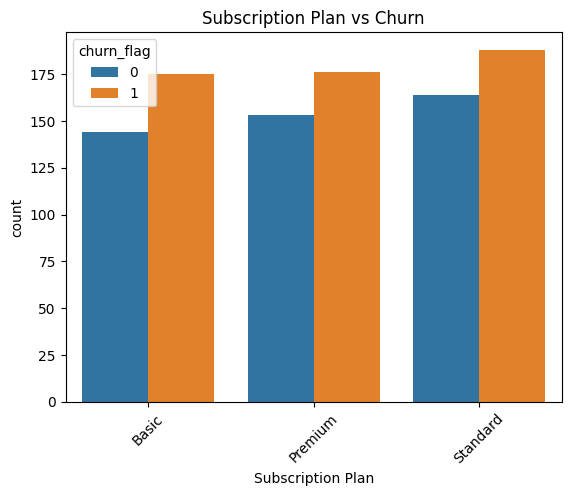

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Subscription Plan', hue='churn_flag', data=df_stats)
plt.title("Subscription Plan vs Churn")
plt.xticks(rotation=45)
plt.show()